<a href="https://colab.research.google.com/github/hellominjo/ml-programming-colab/blob/main/week02_q1_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##📚  **기계학습을 위한 프로그래밍 실습 - 2주차 (Colab)**

**작성자** : AI융합에듀테크전공 조민상(2025421270)

<br/>

### **Q1. 데이터 (2, 5) (4, 9) (6, 13) 이 있습니다. y = w·x + b 의 w와 b는?**

<br />

#### **선형회귀 모델의 학습 과정**
---
주어진 데이터 **(2, 5), (4, 9), (6, 13)**을 이용하여 선형회귀 모델을 학습하고, **가중치(w)와 절편(b)**이 어떻게 결정되는지 확인합니다.

**데이터 (2, 5), (4, 9), (6, 13) · 모델 $\hat{y}=wx+b$ · 손실 $(\hat{y}-y)^2$**

<br />

선형회귀 모델은 입력값 $x$를 이용하여 다음과 같이 예측값 $\hat{y}$을 계산합니다.

$$
\hat{y}=wx+b
$$

여기서 **w는 가중치(기울기)**, **b는 절편**입니다.

모델은 정답인 $w$와 $b$를 미리 알고 있는 것이 아니라, **예측 → Loss 계산 → $w,b$ 조정 → 다시 예측 → Loss 최소화** 과정을 통해 데이터에 가장 적합한 값을 찾아갑니다.

#### **예측값과 손실(Loss) 확인**
---
선형회귀 모델을 학습하여 **w와 b를 구하고 예측값과 Loss를 계산**합니다.

이후 **b=1로 고정하고 w를 0부터 4까지 변화**시키면서 예측값과 Loss의 변화를 표와 그래프로 확인합니다.

**w=2**일 때 예측값은 (5, 9, 13)으로 실제값과 일치하며 **Loss=0**으로 가장 작아집니다.

w = 2  b = 1

[가중치(w)에 따른 예측값과 손실(Loss)]



,가중치 w,모델 예측 ŷ,Loss
0,0,"1, 1, 1",223
1,1,"3, 5, 7",55
2,2,"5, 9, 13",0
3,3,"7, 13, 19",56
4,4,"9, 17, 25",224




[가중치(w)에 따른 Loss 변화]



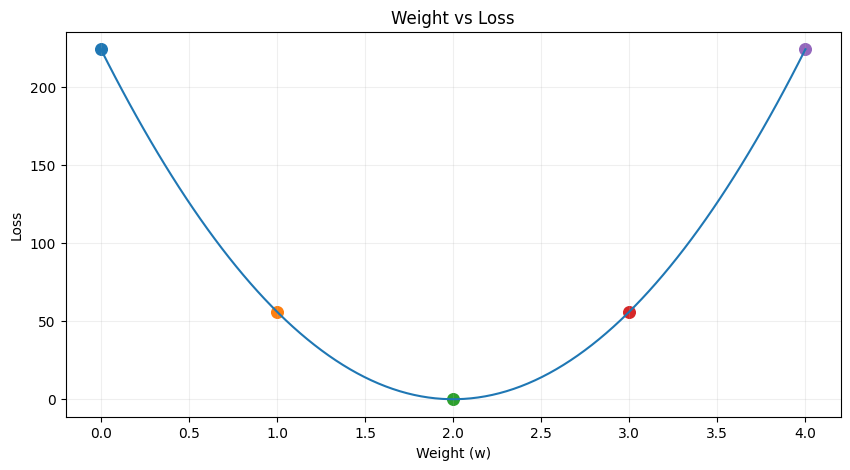

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터
X = np.array([[2], [4], [6]])   # X: 입력값
y = np.array([5, 9, 13])        # y: 실제값

# 2. 선형회귀 모델 생성 및 학습
model = LinearRegression().fit(X, y)

# 3. 기울기(w)와 절편(b)
print("w =", round(model.coef_[0]), " b =", round(model.intercept_))

# 4. w에 따른 Loss 계산
w_values = np.linspace(0, 4, 100)
loss_values = []

b = model.intercept_

for w in w_values:
    y_pred_w = w * X.flatten() + b
    loss_w = np.sum((y_pred_w - y) ** 2)
    loss_values.append(loss_w)


# 5. w별 예측값과 Loss 표
table = []

for w in [0, 1, 2, 3, 4]:
    y_pred_w = w * X.flatten() + b
    loss_w = np.sum((y_pred_w - y) ** 2)

    table.append([
        w,
        ", ".join(map(str, y_pred_w.astype(int))),
        int(loss_w)
    ])

df = pd.DataFrame(table, columns=["가중치 w", "모델 예측 ŷ", "Loss"])

print("\n[가중치(w)에 따른 예측값과 손실(Loss)]\n")
display(df)

# 6. Loss 그래프
print("\n\n[가중치(w)에 따른 Loss 변화]\n")

plt.figure(figsize=(10, 5))
plt.plot(w_values, loss_values)

for w in [0, 1, 2, 3, 4]: # w지점 표시
    y_pred_w = w * X.flatten() + b
    loss_w = np.sum((y_pred_w - y) ** 2)
    plt.scatter(w, loss_w, s=70)

plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.title("Weight vs Loss")
plt.grid(alpha=0.2)

plt.show()